In [2]:
import pandas as pd

skaters = pd.read_csv('../data/skaters.csv')
contracts = pd.read_csv('../data/contracts.csv')

for col in ['AAV', 'Value']:
    contracts[col] = contracts[col].str.replace('[\$,]', '', regex=True).astype(float)

skaters['name_clean'] = skaters['name'].str.lower().str.strip()
contracts['name_clean'] = contracts['Player.ascii'].str.lower().str.strip()

df_skaters = skaters[
    (skaters['season'] == 2024) & 
    (skaters['situation'] == 'all')
].copy()

df = pd.merge(df_skaters, contracts, on='name_clean', how='inner')

df = df[df['Pos.grouped'] != 'G']
df = df.drop_duplicates(subset=['playerId'])

df['points_per_game'] = df['I_F_points'] / df['games_played']

print(f"Successfully merged {len(df)} players.")
df.to_csv('../data/cleaned_nhl_data.csv', index=False)

Successfully merged 880 players.


<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/var/folders/wx/twx5bng55q14gkkwkjdj084m0000gn/T/ipykernel_57332/483157997.py:7: SyntaxWarning: invalid escape sequence '\$'
  contracts[col] = contracts[col].str.replace('[\$,]', '', regex=True).astype(float)
/var/folders/wx/twx5bng55q14gkkwkjdj084m0000gn/T/ipykernel_57332/483157997.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  skaters['name_clean'] = skaters['name'].str.lower().str.strip()


In [3]:
import pandas as pd

df = pd.read_csv('../data/cleaned_nhl_data.csv')

stats_cols = ['AAV', 'PTS', 'Age', 'games_played', 'icetime', 'I_F_xGoals', 'points_per_game']

summary_stats = df[stats_cols].describe().T
print("--- Summary Statistics ---")
print(summary_stats[['count', 'mean', 'std', 'min', '50%', 'max']])

correlations = df[stats_cols].corr()['AAV'].sort_values(ascending=False)
print("\n--- Correlation with AAV ---")
print(correlations)

--- Summary Statistics ---
                 count          mean           std       min           50%  \
AAV              880.0  3.053777e+06  2.792083e+06  750000.0  1.737500e+06   
PTS              880.0  2.213636e+01  2.321747e+01       0.0  1.500000e+01   
Age              878.0  2.712756e+01  4.334859e+00      18.0  2.700000e+01   
games_played     880.0  5.161364e+01  2.947683e+01       1.0  6.300000e+01   
icetime          880.0  5.123901e+04  3.466922e+04      70.0  5.533900e+04   
I_F_xGoals       880.0  8.979398e+00  9.146568e+00       0.0  5.615000e+00   
points_per_game  880.0  3.707089e-01  2.921110e-01       0.0  3.076923e-01   

                          max  
AAV              1.400000e+07  
PTS              1.210000e+02  
Age              4.000000e+01  
games_played     8.500000e+01  
icetime          1.299820e+05  
I_F_xGoals       4.105000e+01  
points_per_game  1.551282e+00  

--- Correlation with AAV ---
AAV                1.000000
PTS                0.753850
points

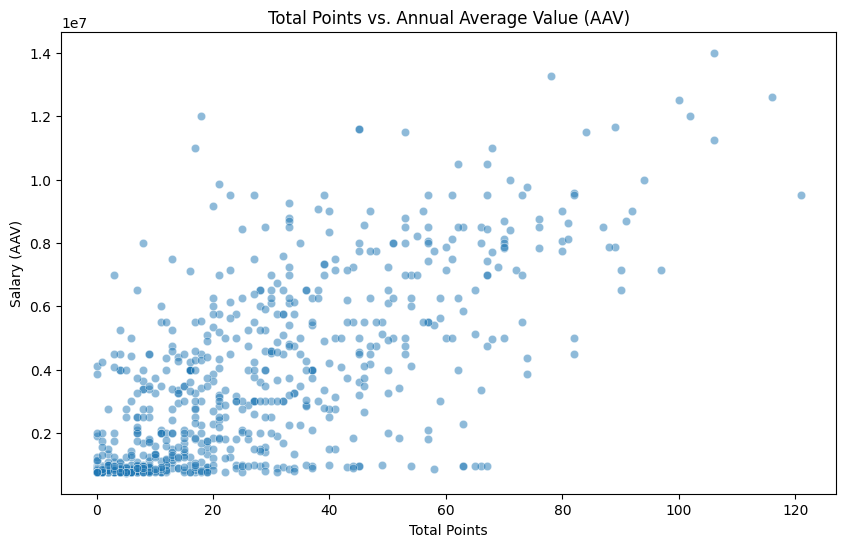

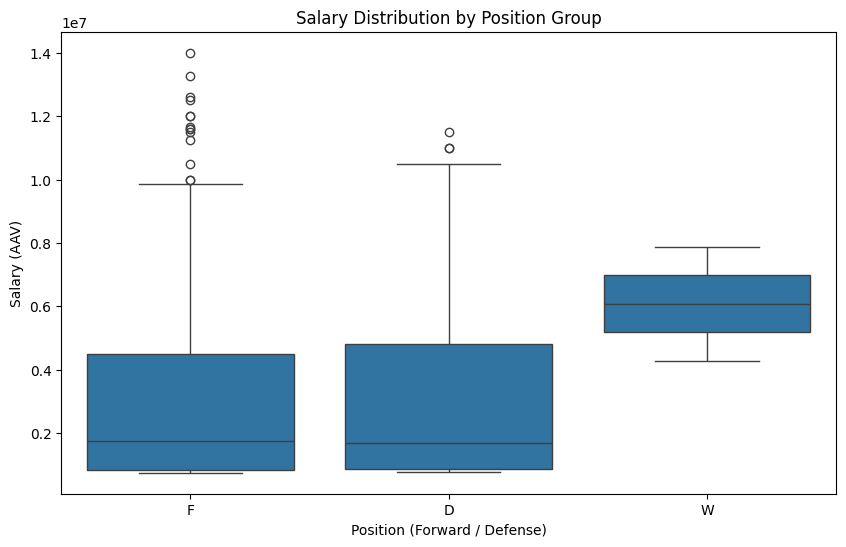

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PTS', y='AAV', alpha=0.5)
plt.title('Total Points vs. Annual Average Value (AAV)')
plt.xlabel('Total Points')
plt.ylabel('Salary (AAV)')
plt.savefig('../progress/plot1.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pos.grouped', y='AAV')
plt.title('Salary Distribution by Position Group')
plt.xlabel('Position (Forward / Defense)')
plt.ylabel('Salary (AAV)')
plt.savefig('../progress/plot2.png')
plt.show()